In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')
print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [3]:
print(df.info())
print("\n")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std  

In [4]:
# Replace 0s with NaN in medically impossible columns
import numpy as np

cols_with_fake_zeros = ['Glucose', 'BloodPressure', 
                         'SkinThickness', 'Insulin', 'BMI']

df[cols_with_fake_zeros] = df[cols_with_fake_zeros].replace(0, np.nan)

# Now check missing values
print("Missing values after fixing fake zeros:")
print(df.isnull().sum())

# A clean copy for model training and train-test preprocessing.
# This copy is created before Outcome-based imputation to prevent target leakage.
df_raw = df.copy()

Missing values after fixing fake zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [5]:
# Fill missing values with median 
# grouped by Outcome - smarter medical approach
cols_to_fill = ['Glucose', 'BloodPressure', 
                'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_fill:
    df[col] = df.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Verify
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


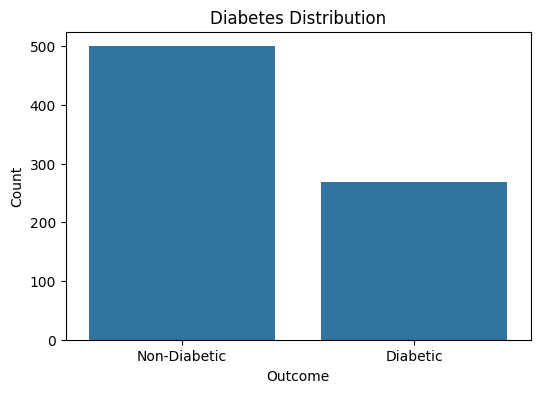

Outcome
0    500
1    268
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class balance
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Distribution')
plt.xticks([0,1], ['Non-Diabetic', 'Diabetic'])
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

print(df['Outcome'].value_counts())

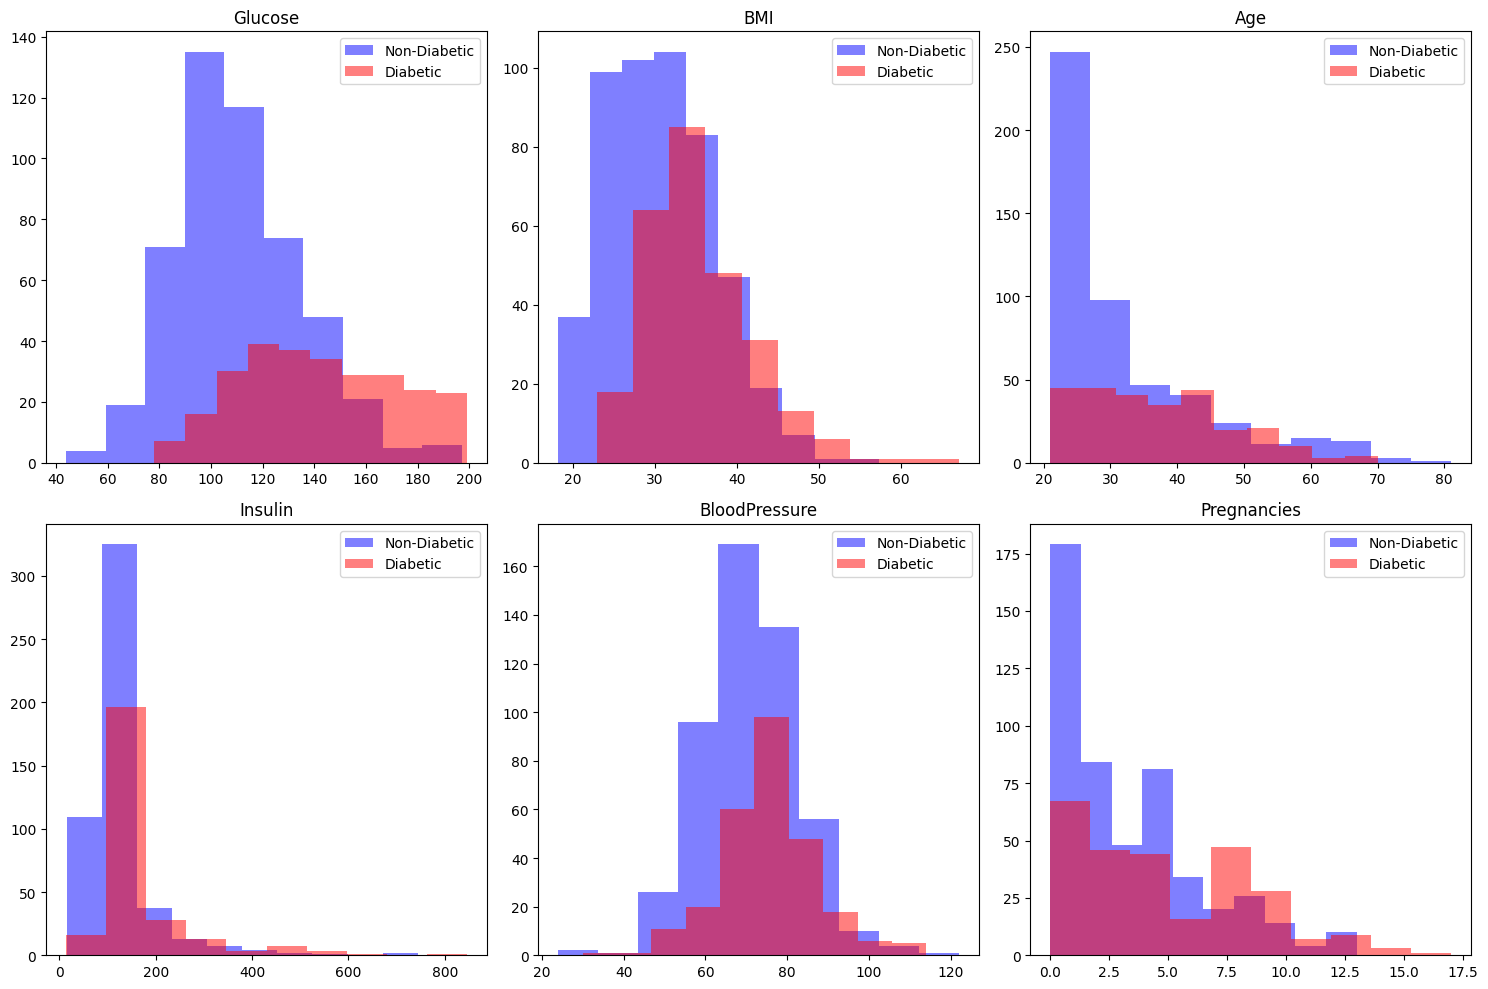

In [7]:
# Distribution of key features by outcome
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = ['Glucose', 'BMI', 
            'Age', 'Insulin',
            'BloodPressure', 'Pregnancies']

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    axes[row, col].hist(
        df[df['Outcome']==0][feature], 
        alpha=0.5, 
        label='Non-Diabetic', 
        color='blue'
    )
    axes[row, col].hist(
        df[df['Outcome']==1][feature], 
        alpha=0.5, 
        label='Diabetic', 
        color='red'
    )
    axes[row, col].set_title(feature)
    axes[row, col].legend()

plt.tight_layout()
plt.show()

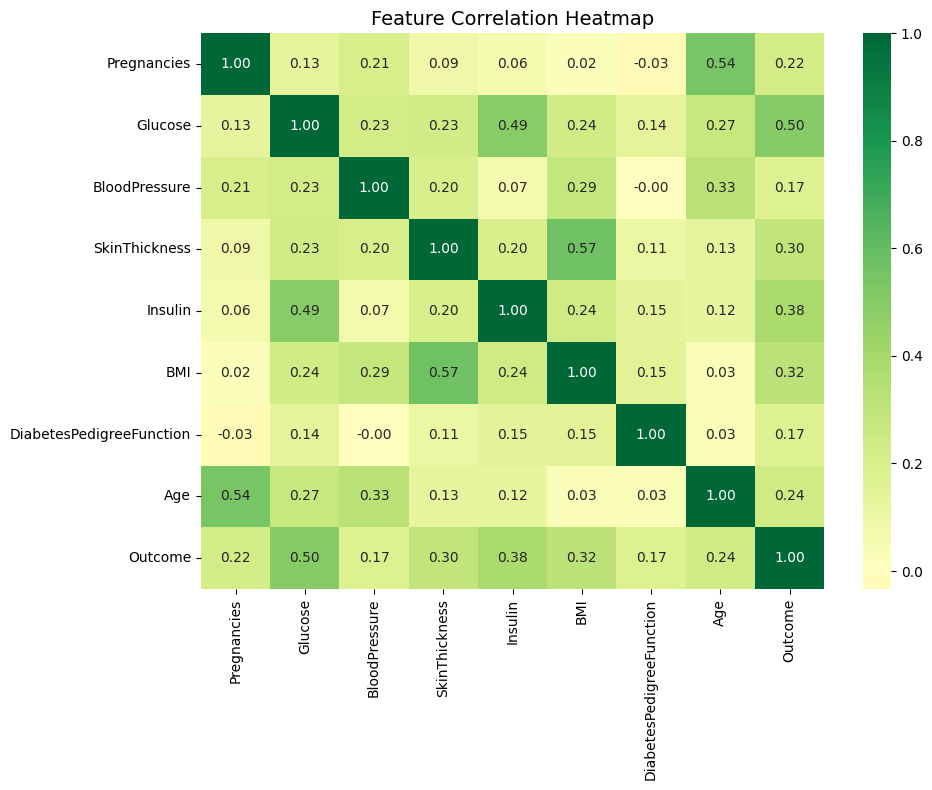

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0)
plt.title('Feature Correlation Heatmap', 
          fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# df_raw se X, y banao — groupby wale df se nahi
X = df_raw.drop(columns=['Outcome'])
y = df_raw['Outcome']

# pehle split karo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# sirf training data se median nikalo, Outcome dekhe bina
cols_to_fill = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
train_medians = X_train[cols_to_fill].median()
X_train[cols_to_fill] = X_train[cols_to_fill].fillna(train_medians)
X_test[cols_to_fill] = X_test[cols_to_fill].fillna(train_medians)

# ab scale karo
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (614, 8)
Testing size: (154, 8)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, 
                             confusion_matrix, 
                             classification_report)

# Train all three models
lr = LogisticRegression(random_state=42)
rf = RandomForestClassifier(n_estimators=100, 
                            random_state=42)
svm = SVC(random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
svm_pred = svm.predict(X_test)

# Compare accuracy
print("="*40)
print("MODEL COMPARISON")
print("="*40)
print(f"Logistic Regression: {accuracy_score(y_test, lr_pred):.2%}")
print(f"Random Forest:       {accuracy_score(y_test, rf_pred):.2%}")
print(f"SVM:                 {accuracy_score(y_test, svm_pred):.2%}")

MODEL COMPARISON
Logistic Regression: 70.78%
Random Forest:       77.27%
SVM:                 74.03%


In [11]:
print("="*40)
print("RANDOM FOREST - DETAILED RESULTS")
print("="*40)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

RANDOM FOREST - DETAILED RESULTS

Confusion Matrix:
[[86 14]
 [21 33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



In [12]:
tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (catches actual diabetics): {sensitivity:.2f}")
print(f"Specificity (catches actual non-diabetics): {specificity:.2f}")

Sensitivity (catches actual diabetics): 0.61
Specificity (catches actual non-diabetics): 0.86


In [13]:
# Adjusted model prioritizing diabetic detection
rf_adjusted = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # This is the key change
    random_state=42
)

rf_adjusted.fit(X_train, y_train)
rf_adj_pred = rf_adjusted.predict(X_test)

print("="*40)
print("ADJUSTED MODEL - MEDICAL PRIORITY")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, rf_adj_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_adj_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_adj_pred))

ADJUSTED MODEL - MEDICAL PRIORITY
Accuracy: 74.68%

Confusion Matrix:
[[84 16]
 [23 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



In [14]:
from xgboost import XGBClassifier

# Calculate imbalance ratio
non_diabetic = (y_train == 0).sum()
diabetic = (y_train == 1).sum()
ratio = non_diabetic / diabetic

print(f"Imbalance ratio: {ratio:.2f}")

# XGBoost with imbalance handling
xgb = XGBClassifier(
    scale_pos_weight=ratio,  # Handles imbalance
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("="*40)
print("XGBOOST - MEDICAL PRIORITY")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Imbalance ratio: 1.87
XGBOOST - MEDICAL PRIORITY
Accuracy: 74.68%

Confusion Matrix:
[[81 19]
 [20 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       100
           1       0.64      0.63      0.64        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [15]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, rf_pred, average='binary', pos_label=1
)
acc = accuracy_score(y_test, rf_pred)
missed_pct = (1 - recall) * 100

print("="*45)
print("DIABETES PREDICTION - FINAL RESULTS")
print("="*45)
print(f"\nBest Model: Random Forest")
print(f"Accuracy:   {acc:.2%}")
print(f"Recall:     {recall:.2f} (catches {recall:.0%} of diabetic patients)")
print(f"Precision:  {precision:.2f}")
print(f"F1-Score:   {f1:.2f}")
print("\nKey Findings:")
print("1. Dataset size limits clinical applicability")
print(f"2. {missed_pct:.0f}% missed diabetic cases — unacceptable")
print("   for real clinical deployment")
print("3. Larger dataset needed for production use")
print("   (see Feature Importance section below for top predictors)")
print(f"\nDataset: 768 patients, 8 clinical features")
print(f"Training: {len(y_train)} patients")
print(f"Testing:  {len(y_test)} patients")
print("="*45)

DIABETES PREDICTION - FINAL RESULTS

Best Model: Random Forest
Accuracy:   77.27%
Recall:     0.61 (catches 61% of diabetic patients)
Precision:  0.70
F1-Score:   0.65

Key Findings:
1. Dataset size limits clinical applicability
2. 39% missed diabetic cases — unacceptable
   for real clinical deployment
3. Larger dataset needed for production use
   (see Feature Importance section below for top predictors)

Dataset: 768 patients, 8 clinical features
Training: 614 patients
Testing:  154 patients


## Why Couldn't We Improve Beyond 77%?

### The Fundamental Problem — Dataset Size

This dataset contains only **768 patients** which is small by 
medical AI standards. The five models tested here (Logistic 
Regression, SVM, Random Forest, class-weight-balanced Random 
Forest, and XGBoost) all plateaued in the 70–77% accuracy range, 
suggesting the dataset itself — not the specific algorithm — is 
the binding constraint here.

### A Data Leakage Lesson

An earlier version of this pipeline imputed missing values 
(Glucose, BloodPressure, SkinThickness, Insulin, BMI) using 
the median **grouped by Outcome**, calculated on the full 
dataset before the train/test split. Since Insulin was missing 
in ~49% of rows and SkinThickness in ~30%, this meant the 
target label was effectively leaking into the features for a 
large share of patients — inflating accuracy to 88.31% and 
making Insulin appear artificially dominant in feature 
importance.

After fixing this (splitting first, imputing from training 
statistics only, with no reference to the target), accuracy 
dropped to a more honest **77.27%**. This isn't a regression — 
it's the removal of a shortcut the model shouldn't have had 
access to in the first place.

### What We Tried and Why It Failed

| Technique | Accuracy | Recall | Why It Failed |
|-----------|----------|--------|----------------|
| Random Forest (baseline) | 77.27% ✅ Best | 0.61 | Honest baseline — highest accuracy, precision, and F1 of all three |
| class_weight='balanced' | 74.68% ❌ | 0.57 | Overcorrected — caught *fewer* diabetics than baseline while lowering accuracy |
| XGBoost + scale_pos_weight | 74.68% ❌ | 0.63 | Caught 1 additional diabetic patient, but at the cost of 5 more false alarms and lower overall accuracy — not a clear win |

### The Clinical Reality

Our best model misses **39 out of every 100 diabetic 
patients** (sensitivity 0.61) — sending them home without 
diagnosis. Attempts to fix this with class-imbalance techniques 
did not meaningfully help. In real clinical settings this is 
unacceptable. Medical AI systems generally require:

- High sensitivity is often prioritized in clinical screening 
  to minimize missed cases
- **Larger, more diverse patient cohorts** for reliable training
- **External validation** on completely separate hospital data

### Key Learning

> Sometimes the data itself is the limitation — not the algorithm. 
> A data scientist's job is to recognize this honestly rather than 
> force-fitting complex solutions onto insufficient data. That 
> includes catching it when your own pipeline was quietly cheating, 
> reporting the corrected result even when it's lower, and 
> resisting the urge to declare a "fix" successful when it isn't.

### What Would Actually Help

1. **More diverse patient data** from larger, multi-center cohorts
2. **More features** — HbA1c levels, family history details
3. **SMOTE** — Synthetic Minority Oversampling to generate 
   artificial diabetic patient samples
4. **Ensemble stacking** — combining multiple models together

### Conclusion

This project demonstrates that **domain knowledge matters as 
much as technical skill** in Healthcare AI. Recognizing the 
clinical implications of a 39% miss rate, catching a data 
leakage bug that was hiding the true performance, and honestly 
reporting that two standard imbalance-correction techniques 
*didn't* help — that combination is exactly what responsible 
medical AI research looks like.

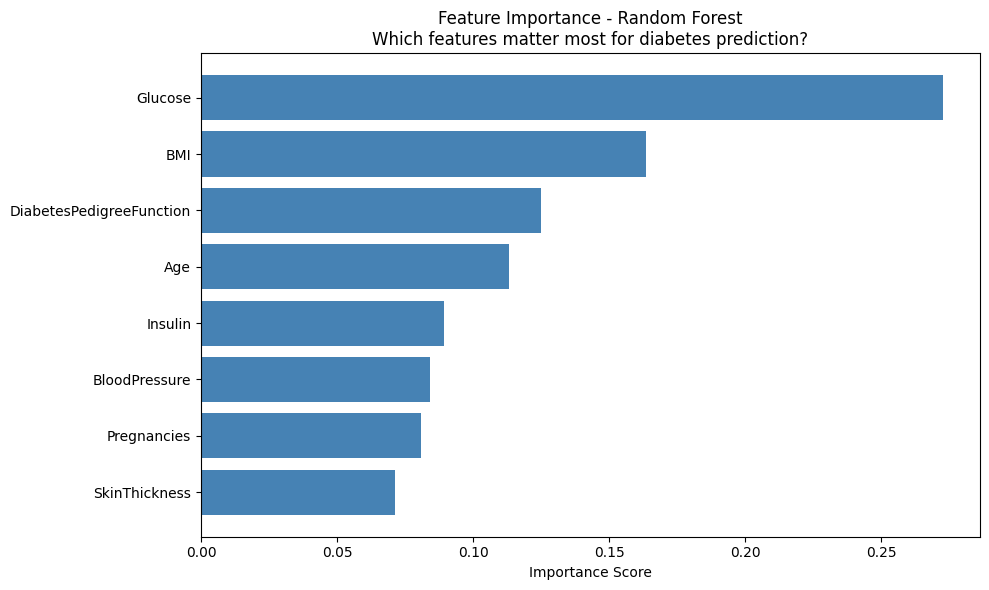


Feature Importance Ranking:
                    Feature  Importance
1                   Glucose    0.272616
5                       BMI    0.163688
6  DiabetesPedigreeFunction    0.124927
7                       Age    0.113057
4                   Insulin    0.089395
2             BloodPressure    0.084337
0               Pregnancies    0.080793
3             SkinThickness    0.071187


In [16]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], 
         feature_importance['Importance'],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest\n'
          'Which features matter most for diabetes prediction?',
          fontsize=12)
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(feature_importance.sort_values(
    'Importance', ascending=False
))

In [17]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, rf_pred, average='binary', pos_label=1
)
acc_rf = accuracy_score(y_test, rf_pred)
acc_lr = accuracy_score(y_test, lr_pred)
acc_svm = accuracy_score(y_test, svm_pred)
missed_pct = (1 - recall) * 100

top3 = feature_importance.sort_values('Importance', ascending=False).head(3)

print("="*50)
print("DIABETES PREDICTION - FINAL SUMMARY")
print("="*50)
print(f"\nDataset: Pima Indians Diabetes Database")
print(f"Total Patients: 768")
print(f"Training Size: {len(y_train)} patients")
print(f"Testing Size:  {len(y_test)} patients")
print(f"Features: 8 clinical features")
print("\n--- MODEL COMPARISON ---")
print(f"Logistic Regression: {acc_lr:.2%}")
print(f"SVM:                 {acc_svm:.2%}")
print(f"Random Forest:       {acc_rf:.2%} 🏆 Best")
print("\n--- BEST MODEL METRICS ---")
print(f"Accuracy:  {acc_rf:.2%}")
print(f"Recall:    {recall:.2f} (catches {recall:.0%} diabetic patients)")
print(f"Precision: {precision:.2f}")
print(f"F1-Score:  {f1:.2f}")
print("\n--- TOP PREDICTIVE FEATURES ---")
for i, row in enumerate(top3.itertuples(), 1):
    print(f"{i}. {row.Feature} (importance: {row.Importance:.3f})")
print("\n--- CLINICAL CONCLUSION ---")
print(f"Model misses {missed_pct:.0f}% of diabetic patients")
print(f"Not yet suitable for clinical deployment")
print(f"Larger dataset needed for production use")
print("="*50)

DIABETES PREDICTION - FINAL SUMMARY

Dataset: Pima Indians Diabetes Database
Total Patients: 768
Training Size: 614 patients
Testing Size:  154 patients
Features: 8 clinical features

--- MODEL COMPARISON ---
Logistic Regression: 70.78%
SVM:                 74.03%
Random Forest:       77.27% 🏆 Best

--- BEST MODEL METRICS ---
Accuracy:  77.27%
Recall:    0.61 (catches 61% diabetic patients)
Precision: 0.70
F1-Score:  0.65

--- TOP PREDICTIVE FEATURES ---
1. Glucose (importance: 0.273)
2. BMI (importance: 0.164)
3. DiabetesPedigreeFunction (importance: 0.125)

--- CLINICAL CONCLUSION ---
Model misses 39% of diabetic patients
Not yet suitable for clinical deployment
Larger dataset needed for production use


## Project Conclusion

### What This Project Achieved
This project successfully built a diabetes prediction 
model achieving **77.27% accuracy** using Random Forest 
on clinical patient data.

### Unique Approach
Unlike typical ML projects, this analysis incorporated 
**medical domain knowledge** throughout:
- Identified fake zeros as missing values using 
  clinical understanding
- Used median imputation learned only from training data — 
  deliberately avoiding any reference to the outcome label, 
  after an earlier version was found to leak target 
  information this way
- Interpreted results using sensitivity and specificity
- Evaluated model fitness for real clinical deployment

### Honest Limitations
- 768 patients is insufficient for clinical deployment
- 39% missed diabetic patients is clinically unacceptable
- Larger dataset with more features needed

### Key Insight
> Glucose is both the most strongly correlated feature with 
> diabetes and the top predictive feature by model importance 
> — consistent with its role as the direct clinical diagnostic 
> marker. An earlier version of this pipeline had Insulin 
> ranked highest instead, which turned out to be an artifact 
> of a data leakage bug in the imputation step, not a genuine 
> biological signal.

### Author
Mohammad Danish | BCA Online, Amity University  
Healthcare AI Researcher in Progress  
GitHub: github.com/Danish925